(160, 301, 301)


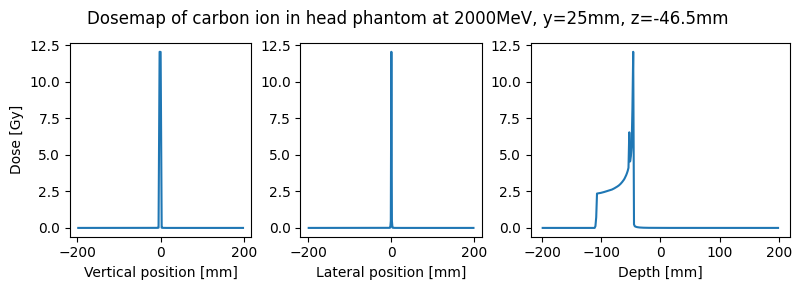

In [24]:
import numpy as np
import pandas as pd
import glob
import os
import sys
import matplotlib.pyplot as plt
import torch
import matplotlib.gridspec as gridspec
from torch.utils.data import Dataset
from torch.utils.data import DataLoader


# xzy
datasets = {
    "Data1": {
        "number_voxels": [256 ,256 ,126],
        "voxel_dim": [0.707031*2, 0.707031*2, 1.25*2],
        "origin": [-181, -181, -229],
        "end" :[181,181,86],
        "positions_x": [-110],
        "positions_y": [-50, -25, 0, 25, 50, 75],
        "positions_z": [-146.5, -121.5, -96.5, -71.5, -46.5],
        "voxel_center": [0,0,-71.5]
    },
    "Data2": {
        "number_voxels": [256 ,256 ,159],
        "voxel_dim": [0.759766*2, 0.759766*2, 1.25*2],
        "origin": [-194.5, -194.5, -271],
        "end" :[194.5,194.5,126.5],
        "positions_x": [-110],
        "positions_y": [-25, 0, 25, 50, 75],
        "positions_z": [-146.5, -121.5, -96.5, -71.5], # exclude -171.5
        "voxel_center": [0,0,-72.25]
    },
    "Data4": {
        "number_voxels": [256 ,256 ,125],
        "voxel_dim": [0.666016*2, 0.666016*2, 1.25*2],
        "origin": [-170.5,-170.5, -188.75],
        "end" :[170.5,170.5,123.75],
        "positions_x": [-110],
        "positions_y": [-50, -25, 0, 25, 50, 75],
        "positions_z": [-71.5, -46.5, -21.5, 3.5],
        "voxel_center": [0,0,-32.5]
    },
    "Data5": {
        "number_voxels": [256 ,256 ,131],
        "voxel_dim": [0.689453*2, 0.689453*2, 1.25*2],
        "origin": [-176.5, -176.5, -208.25],
        "end" :[176.5,176.5,119.25],
        "positions_x": [-110],
        "positions_y": [-50, -25, 0, 25, 50, 75],
        "positions_z": [-96.5, -71.5, -46.5, -21.5],
        "voxel_center": [0,0,-44.5]
    },
    "Data7": {
        "number_voxels": [256 ,256 ,136],
        "voxel_dim": [0.683594*2, 0.683594*2, 1.25*2],
        "origin": [-175, -175, -199.25],
        "end" :[175,175,140.75],
        "positions_x": [-110],
        "positions_y": [-25, 0, 25, 50, 75],
        "positions_z": [-96.5, -71.5, -46.5, -21.5],
        "voxel_center": [0,0,-29.25]
    },
    "Data8": {
        "number_voxels": [256 ,256 ,136],
        "voxel_dim": [0.726562*2, 0.726562*2, 1.25*2],
        "origin": [-186, -186, -186.25],
        "end" :[186,186,153.75],
        "positions_x": [-110],
        "positions_y": [-25, 0, 25, 50],
        "positions_z": [-96.5, -71.5, -46.5, -21.5, 3.5],
        "voxel_center": [0,0,-16.25]
    },
    "water": {
        "number_voxels": [300 ,300 ,160],
        "voxel_dim": [0.666016*2, 0.666016*2, 1.25*2],
        "origin": [-200,-200, -200],
        "end" :[200,200,200],
        "positions_x": [-110],
        "positions_y": [-50, -25, 0, 25, 50, 75],
        "positions_z": [-71.5, -46.5, -21.5, 3.5],
        "voxel_center": [0,0,-32.5]
    }
}

def plot_brain(dose, data): #plot with shape zyx 126*256*256

    DELTA_X = data["voxel_dim"][0]
    DELTA_Y=data["voxel_dim"][1]
    DELTA_Z=data["voxel_dim"][2]


    x_vals = np.arange(data["origin"][0], data["end"][0]-1, DELTA_X)
    x_vals = x_vals + DELTA_X/2

    y_vals = np.arange(data["origin"][0], data["end"][1]-1, DELTA_Y)
    y_vals = y_vals + DELTA_Y/2

    z_vals = np.arange(data["origin"][2], data["end"][2]-DELTA_Z, DELTA_Z) 
    z_vals = 1+ z_vals + DELTA_Z/2

    max_index = np.unravel_index(dose.argmax(), dose.shape)


    dose_x = []
    dose_y = []
    dose_z = []
    for x in range(data["number_voxels"][0]):
        dose_x.append(dose[int(max_index[0]), int(max_index[1]),x])        
    for y in range(data["number_voxels"][1]):
        dose_y.append(dose[int(max_index[0]),y,int(max_index[2])])
    for z in range(data["number_voxels"][2]):        
        dose_z.append(dose[z, int(max_index[1]),int(max_index[2])])
    del dose_z[0]
    # Create a 2x3 grid of subplots

    fig = plt.figure(figsize=(8, 3))
    gs = gridspec.GridSpec(1, 3, width_ratios=[0.7, 0.7, 1])  # 3 plots
    ax2 = plt.subplot(gs[2])
    ax2.plot(x_vals, dose_x)
    ax2.set_yscale('linear')
    ax2.set_xlabel('Depth [mm]')

    #axs[2].set_title('Dose Distribution in water along X direction')

    ax1 = plt.subplot(gs[1])
    ax1.plot(y_vals, dose_y)
    ax1.set_yscale('linear')
    ax1.set_xlabel('Lateral position [mm]')
    #ax1.set_ylabel('Dose [Gy]')
    #axs[1].set_title('Dose Distribution in water along Y direction')

    ax0 = plt.subplot(gs[0])
    ax0.plot(z_vals, dose_z)
    ax0.set_yscale('linear')
    ax0.set_xlabel('Vertical position [mm]')
    ax0.set_ylabel('Dose [Gy]')

    plt.suptitle('Dosemap of carbon ion in head phantom at 2000MeV, y=25mm, z=-46.5mm', ha='center', va='top', y=0.95)
    plt.tight_layout()
    plt.show()  

data = "water"
dose= np.load("/home/tappay01/new_data/watersimulation/DATASET4_2000MeV.npy")
print(dose.shape)
plot_brain(dose, datasets[data])

(136, 256, 256)


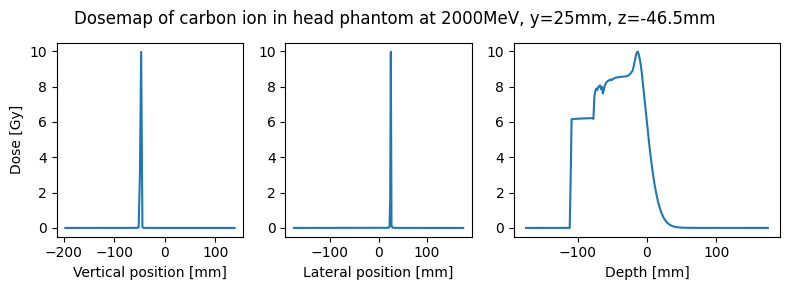

In [25]:
data = "Data7"
dose= np.load("/home/tappay01/new_data/data7/Data7_2000MeV_25Mm_-46.5Mm.npy")
print(dose.shape)
plot_brain(dose, datasets[data])

(131, 256, 256)


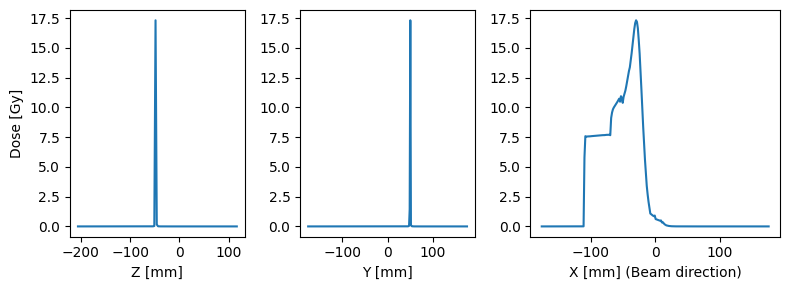

In [23]:
data = "Data5"
dose= np.load("/home/tappay01/new_data/data5/Data5_1500MeV_50Mm_-46.5Mm.npy")
print(dose.shape)
plot_brain(dose, datasets[data])

(125, 256, 256)


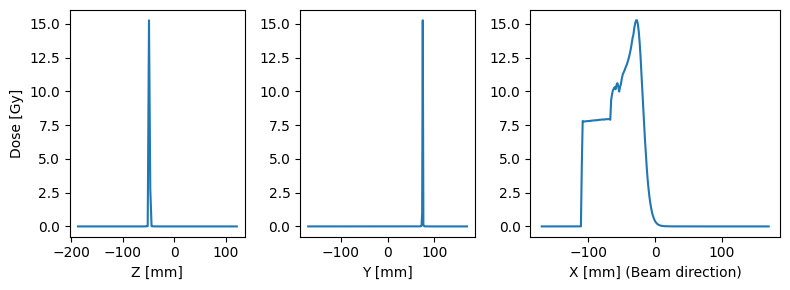

In [5]:
data = "Data4"
dose= np.load("/home/tappay01/new_data/data4/Data4_1500MeV_75Mm_-46.5Mm.npy")
print(dose.shape)
plot_brain(dose, datasets[data])

(159, 256, 256)


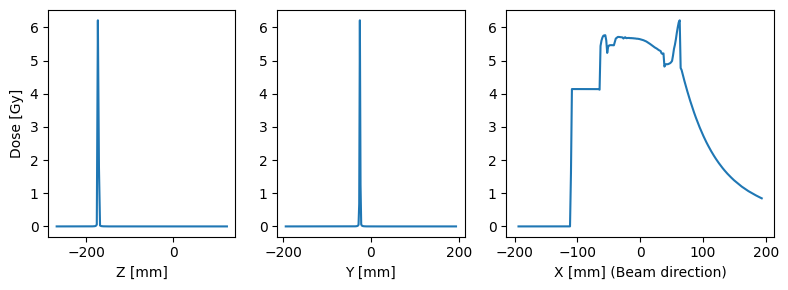

In [3]:
data = "Data2"
dose= np.load('/home/tappay01/new_data/data2/Data2_3000MeV_-25Mm_-171.5Mm.npy')
print(dose.shape)
plot_brain(dose, datasets[data])